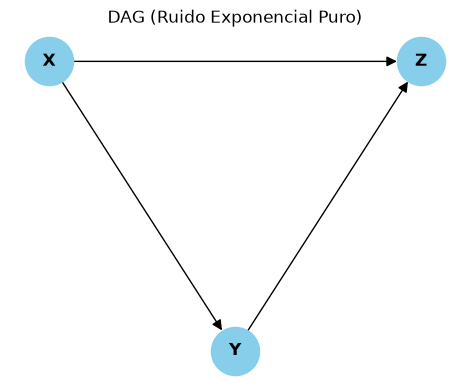


######################################################################
INICIANDO EXPERIMENTO 1 PARA SEMILLA = 155
######################################################################

INICIANDO EXPERIMENTO PARA N = 50
 -> Entrenando MSE para N=50 y semilla=155...
Using device: cpu
Early stopping at step 11
Using device: cpu
Early stopping at step 106
 -> Entrenando HSIC para N=50 y semilla=155...
Using device: cpu
Early stopping at step 15
Using device: cpu
Early stopping at step 11
 -> Entrenando HYBRID_ALPHA0.1 para N=50 y semilla=155...
Using device: cpu
Early stopping at step 11
Using device: cpu
Early stopping at step 63
 -> Entrenando HYBRID_ALPHA0.2 para N=50 y semilla=155...
Using device: cpu
Early stopping at step 11
Using device: cpu
Early stopping at step 115
 -> Entrenando HYBRID_ALPHA0.3 para N=50 y semilla=155...
Using device: cpu
Early stopping at step 11
Using device: cpu
Early stopping at step 109
 -> Entrenando HYBRID_ALPHA0.4 para N=50 y semilla=155...
Using devic

,Experiment,Seed,Loss,Conf,Alpha,Beta,N,MSE Y,MAE Y,"HSIC(Y,X)",MSE Z,MAE Z,"HSIC(Z,X)","HSIC(Z,Y)",dHSIC Total,MMD,RF Acc
1,1,155,hsic,HSIC,0.0,1.0,50,2.72638,0.94353,15.24036,10.60895,1.57794,6.71859,15.82704,0.00920,0.05437,0.70000
12,1,155,hsic,HSIC,0.0,1.0,100,1.79185,0.94294,36.43062,5.45732,1.51929,22.80444,44.11349,0.00509,0.07321,0.75000
23,1,155,hsic,HSIC,0.0,1.0,300,2.50535,1.14117,647.09861,8.64491,1.85708,307.25693,559.90538,0.00448,0.20087,0.88333
34,1,155,hsic,HSIC,0.0,1.0,500,2.96481,1.20765,1858.21386,11.42498,1.92507,1023.66289,1889.19096,0.00290,0.11179,0.86000
45,1,155,hsic,HSIC,0.0,1.0,700,4.88509,1.23855,3144.74056,133.93046,2.47024,1274.62883,2789.64525,0.00412,0.13796,0.82857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,10,1759,mse,MSE,1.0,0.0,100,1.85381,1.02167,47.94546,2.34483,1.11561,31.82175,41.09774,0.00408,0.05853,0.75000
616,10,1759,mse,MSE,1.0,0.0,300,0.96587,0.75637,74.33783,5.61974,1.15515,66.31146,62.46011,0.00267,0.03233,0.53333
627,10,1759,mse,MSE,1.0,0.0,500,1.23039,0.80573,121.22550,1.20908,0.76869,102.62837,131.46449,0.00139,0.02111,0.61000
638,10,1759,mse,MSE,1.0,0.0,700,1.07392,0.79971,772.88000,1.02203,0.76126,187.11626,164.48253,0.00124,0.04924,0.65000


In [14]:
# ==============================================================================
# BLOQUES 2 y 3 REESTRUCTURADOS: EVALUACIÓN MULTI-N CON MAE (CORREGIDO)
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import time
import numpy as np
import re
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed


# --- [PASO 1: DEFINICIÓN DE FUNCIONES AUXILIARES PARA EVITAR NAMEERROR] ---

def generate_synthetic_triangle_data_pure_gausian (num_samples=2000, seed=42, escala=1.0):
    """Genera el SCM No Lineal con ruido Gausiano Puro."""
    np.random.seed(seed)
    eps_X = np.random.exponential(scale=escala, size=num_samples) - escala
    eps_Y = np.random.exponential(scale=escala, size=num_samples) - escala
    eps_Z = np.random.exponential(scale=escala, size=num_samples) - escala
    
    X = eps_X
    Y = 0.5 * (X ** 2) + np.sin(X) + eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuración de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()


# --- [PASO 2: CONFIGURACIÓN DEL EXPERIMENTO] ---

# Definimos los tamaños de muestra (N) que queremos auditar
valores_N_experimento = [50, 100, 300, 500, 700, 1000]
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)
semillas_experimento = np.random.default_rng(123).integers(1, 10000, size=10) # Ejecutar el experimento con 10 semillas distintas

# Estructura del Grafo Causal Criterio
graph_triangle = nx.DiGraph([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])

# Mapeo de tipos continuos para la KAN
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {}

# Dibujar el DAG estructural para la documentación de tu TFM
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG (Ruido Exponencial Puro)")
plt.show()

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

registros_tabla_final = []


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACIÓN] ---

for experiment_id, seed in enumerate(semillas_experimento, start=1):
    print(f"\n" + "#"*70)
    print(f"INICIANDO EXPERIMENTO {experiment_id} PARA SEMILLA = {seed}")
    print("#"*70)

    for N_actual in valores_N_experimento:
        print(f"\n" + "="*70)
        print(f"INICIANDO EXPERIMENTO PARA N = {N_actual}")
        print("="*70)
        
        # 1. Generación de datos escalada al N actual
        data_triangle = generate_synthetic_triangle_data_pure_gausian(num_samples=N_actual, seed=seed, escala=1.0)
        factual_train_d, factual_eval_d = train_test_split(data_triangle, test_size=0.5, random_state=42)
        
        datos_reales_test = factual_eval_d[['X', 'Y', 'Z']].to_numpy()
        num_muestras_eval = len(factual_eval_d)
        
        # 2. Definición de las estrategias (Baselines + Híbridos)
        strategies = ['mse', 'hsic'] + [f"hybrid_alpha{round(a,2)}" for a in valores_alpha_candidatos if a != 0.0 and a != 1.0]
        
        for strategy_key in strategies:
            if strategy_key == "mse":
                strategy_name, alpha_val, beta_val = "mse", 1.0, 0.0
            elif strategy_key == "hsic":
                strategy_name, alpha_val, beta_val = "hsic", 0.0, 1.0
            else:
                strategy_name = "hybrid"
                alpha_val = round(float(re.findall(r"[-+]?\d*\.\d+|\\d+", strategy_key)[0]), 2)
                beta_val = round(1.0 - alpha_val, 2)
                
            # Llamada segura con argumentos locales pasados explícitamente
            params_estructurados = crear_estructura_nodos(
                graph_triangle, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
            )
            
            print(f" -> Entrenando {strategy_key.upper()} para N={N_actual} y semilla={seed}...")
            model = kan_model_mixed(graph_triangle, params_estructurados)
            model.fit(data=factual_train_d)
            
            # 3. Diagnóstico en el conjunto de evaluación de este N
            conf_name = strategy_key.upper() if strategy_name != "hybrid" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
            fila = {
                'Experiment': experiment_id,
                'Seed': seed,
                'Loss': strategy_name,
                'Conf': conf_name,
                'Alpha': alpha_val,
                'Beta': beta_val,
                'N': N_actual
            }
            
            try:
                if hasattr(model, 'get_residuals'):
                    residuos = model.get_residuals(factual_eval_d)
                    X_test = factual_eval_d['X'].to_numpy().flatten()
                    Y_test = factual_eval_d['Y'].to_numpy().flatten()
                    sistema_residuos = [X_test]
                    
                    if 'Y' in residuos and residuos['Y'] is not None:
                        rY = preparar_residuo(residuos['Y'])
                        sistema_residuos.append(rY)
                        fila['MSE Y'] = round(float(np.mean(rY**2)), 5)
                        fila['MAE Y'] = round(float(np.mean(np.abs(rY))), 5)
                        fila['HSIC(Y,X)'] = round(float(HSIC(rY, X_test)), 5)
                        
                    if 'Z' in residuos and residuos['Z'] is not None:
                        rZ = preparar_residuo(residuos['Z'])
                        sistema_residuos.append(rZ)
                        fila['MSE Z'] = round(float(np.mean(rZ**2)), 5)
                        fila['MAE Z'] = round(float(np.mean(np.abs(rZ))), 5)
                        fila['HSIC(Z,X)'] = round(float(HSIC(rZ, X_test)), 5)
                        fila['HSIC(Z,Y)'] = round(float(HSIC(rZ, Y_test)), 5)
                    
                    fila['dHSIC Total'] = round(float(max(0.0, dHSIC(*sistema_residuos))), 5)

                if hasattr(model, 'draw_samples'):
                    datos_gen = model.draw_samples(num_samples=num_muestras_eval)[['X', 'Y', 'Z']].to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

            except Exception as e:
                print(f"   [Error en evaluación] {conf_name} con N={N_actual}: {e}")
                
            registros_tabla_final.append(fila)

# --- [PASO 4: CONSTRUCCIÓN DE LA TABLA MAESTRA] ---
df_final_multi_n = pd.DataFrame(registros_tabla_final)
df_final_multi_n['es_hibrido'] = df_final_multi_n['Conf'].str.contains('HYBRID')
df_final_multi_n = df_final_multi_n.sort_values(by=['Experiment', 'Seed', 'Loss', 'N', 'es_hibrido', 'Alpha', 'Beta'], ascending=[True, True, True, True, True, True, True])
# Reordenar columnas para mostrar primero experimento, semilla y función de pérdida
base_cols = ['Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N']
other_cols = [c for c in df_final_multi_n.columns if c not in base_cols + ['es_hibrido']]
df_final_multi_n = df_final_multi_n[base_cols + other_cols]

print("\n--- MATRIZ DE DIAGNÓSTICO MULTI-N FINALIZADA ---")
display(df_final_multi_n)

# --- [PASO 5: GUARDADO DE RESULTADOS EN CSV] ---
carpeta_tablas = "tablas"
ruta_archivo = os.path.join(carpeta_tablas, "aditivo_exponencial_2.csv")

# Crear la carpeta si no existe
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)

# Guardar el DataFrame
df_final_multi_n.to_csv(ruta_archivo, index=False)

In [15]:
# ==============================================================================
# PASO 6: TABLA RESUMEN CON MEDIA Y DESVIACIÓN TÍPICA
# (Media ± Std para CADA combinación de Alpha/Beta a través de las 10 semillas)
# ==============================================================================
print("\n" + "="*100)
print("TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)")
print("="*100)

# Identificar métricas numéricas (excluyendo metadatos)
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_numericas = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Procesar por tamaño de muestra (N) de forma independiente
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n\n{'#'*100}")
    print(f"# EXPERIMENTO: N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    # Agrupar por (Alpha, Beta) - esto captura cada combinación única
    resumen_por_config = []
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        # group_config contiene las 10 repeticiones (semillas) para esta combinación
        
        fila_resumen = {
            'Alpha': alpha_val,
            'Beta': beta_val,
            'Loss': group_config['Loss'].iloc[0],  # La Loss es la misma para esta combinación
            'Conf': group_config['Conf'].iloc[0],  # Nombre de la configuración
            'Num_Seeds': len(group_config)  # Debe ser 10
        }
        
        # Para cada métrica, calcular media y std de las 10 semillas
        for metrica in metricas_numericas:
            media_metrica = group_config[metrica].mean()
            std_metrica = group_config[metrica].std()
            # Guardar como valores separados para CSV
            fila_resumen[f'{metrica}_mean'] = round(media_metrica, 5)
            fila_resumen[f'{metrica}_std'] = round(std_metrica, 5)
        
        resumen_por_config.append(fila_resumen)
    
    # Convertir a DataFrame
    df_resumen_n = pd.DataFrame(resumen_por_config)
    
    # Ordenar por Loss (mse, hsic, hybrid) y luego por Alpha descendente
    orden_loss = {'mse': 0, 'hsic': 1, 'hybrid': 2}
    df_resumen_n['loss_order'] = df_resumen_n['Loss'].map(orden_loss)
    df_resumen_n = df_resumen_n.sort_values(['loss_order', 'Alpha'], ascending=[True, False])
    df_resumen_n = df_resumen_n.drop('loss_order', axis=1)
    
    print(f"Tabla resumen para N={n_val}:\n")
    display(df_resumen_n)
    
    # Guardar cada tabla N en un CSV separado
    ruta_resumen_n = os.path.join("tablas", f"resumen_n_{n_val}_aditivo_exponencial_2.csv")
    if not os.path.exists("tablas"):
        os.makedirs("tablas")
    df_resumen_n.to_csv(ruta_resumen_n, index=False)
    print(f"\n✓ Tabla resumen guardada en: {ruta_resumen_n}\n")

# Crear también una tabla consolidada con formato legible "media ± std"
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media ± Std para cada métrica")
print(f"{'='*100}\n")

for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n{'#'*100}")
    print(f"# N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        conf_name = group_config['Conf'].iloc[0]
        loss_name = group_config['Loss'].iloc[0]
        
        print(f"\n{'-'*100}")
        print(f"Config: {conf_name:30s} | Alpha={alpha_val:.2f}, Beta={beta_val:.2f}, Loss={loss_name} | Seeds: {len(group_config)}")
        print(f"{'-'*100}")
        
        resumen_row = {}
        for metrica in metricas_numericas:
            media = group_config[metrica].mean()
            std = group_config[metrica].std()
            resumen_row[metrica] = f"{media:.5f} ± {std:.5f}"
        
        df_readable = pd.DataFrame([resumen_row]).T
        df_readable.columns = ['Media ± Std']
        display(df_readable)


TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)


####################################################################################################
# EXPERIMENTO: N = 50 MUESTRAS
####################################################################################################

Tabla resumen para N=50:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,10,3.95164,5.09848,1.06930,0.31643,16.49834,...,12.47326,7.48312,18.08426,10.15872,0.00715,0.00123,0.11824,0.09136,0.76,0.11738
0,0.0,1.0,hsic,HSIC,10,4.77364,7.62560,1.16490,0.33915,20.45162,...,14.09349,7.85802,22.48403,7.11356,0.00718,0.00177,0.16586,0.10423,0.70,0.13333
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,10,3.84841,4.88950,1.06771,0.30947,16.38715,...,12.62446,7.40977,17.83643,9.87693,0.00740,0.00156,0.11758,0.09063,0.72,0.12293
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,10,3.94083,4.87471,1.07855,0.30890,16.71773,...,13.57916,8.14875,18.42421,9.92914,0.00730,0.00145,0.11869,0.09236,0.74,0.10750
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,10,3.84899,4.91306,1.08455,0.30324,17.81984,...,13.31307,8.35325,17.22535,8.87659,0.00722,0.00155,0.11800,0.09290,0.75,0.11785
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,10,3.68858,4.50662,1.07647,0.29086,17.25593,...,12.92385,8.34300,16.93543,8.64636,0.00757,0.00172,0.11782,0.09255,0.75,0.10801
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,10,3.75620,4.56658,1.07698,0.29579,16.82472,...,11.98778,7.64246,17.96746,8.96331,0.00725,0.00129,0.11726,0.09182,0.75,0.10801
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,10,3.61260,4.65927,1.07386,0.28891,17.87885,...,11.83562,7.60292,16.76215,8.16023,0.00739,0.00170,0.11896,0.09005,0.72,0.12293
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,10,3.51638,4.68720,1.04541,0.29682,16.67229,...,11.75598,7.61009,15.04642,7.55194,0.00807,0.00192,0.12038,0.08988,0.75,0.12693
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,10,3.45450,4.69142,1.04148,0.30119,16.00928,...,11.80096,7.51183,15.38850,7.55247,0.00789,0.00208,0.11625,0.08938,0.70,0.12472



✓ Tabla resumen guardada en: tablas/resumen_n_50_aditivo_exponencial_2.csv



####################################################################################################
# EXPERIMENTO: N = 100 MUESTRAS
####################################################################################################

Tabla resumen para N=100:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,10,3.36787,3.75381,0.98107,0.20352,38.76366,...,31.35402,12.78903,36.26239,10.90486,0.00465,0.00132,0.08186,0.05614,0.700,0.08498
0,0.0,1.0,hsic,HSIC,10,3.90563,4.24567,1.12909,0.23289,66.50497,...,46.92944,15.28085,63.29325,26.11595,0.00551,0.00208,0.14026,0.08401,0.770,0.10593
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,10,2.71575,3.31626,0.95144,0.18614,38.69360,...,31.19752,12.97505,32.92394,12.15843,0.00475,0.00118,0.08464,0.05745,0.705,0.08644
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,10,3.61387,4.02998,0.99538,0.20327,38.61896,...,30.57504,13.30720,32.61881,12.62127,0.00474,0.00110,0.08257,0.05627,0.705,0.07976
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,10,2.62721,3.08004,0.94595,0.18272,39.05034,...,28.95243,12.80673,33.04309,13.99645,0.00465,0.00123,0.08282,0.05850,0.725,0.07546
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,10,2.62395,3.07600,0.94519,0.19363,40.72676,...,27.34473,13.17754,30.31128,12.23206,0.00469,0.00157,0.08302,0.05987,0.750,0.06667
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,10,2.60924,3.07714,0.93729,0.20122,39.95648,...,27.03339,13.26514,28.32380,9.55515,0.00447,0.00145,0.08141,0.06122,0.735,0.10288
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,10,2.64679,3.06214,0.94727,0.20633,41.61811,...,30.99177,19.20860,39.43850,25.50865,0.00449,0.00163,0.07904,0.06021,0.715,0.06258
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,10,2.66256,3.00765,0.96083,0.20294,43.66161,...,32.58984,15.46926,38.31460,25.46138,0.00464,0.00158,0.08502,0.07214,0.705,0.07619
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,10,2.56312,2.96666,0.94784,0.21394,41.39235,...,27.41526,15.62676,29.25893,24.74049,0.00462,0.00174,0.08331,0.07043,0.695,0.10659



✓ Tabla resumen guardada en: tablas/resumen_n_100_aditivo_exponencial_2.csv



####################################################################################################
# EXPERIMENTO: N = 300 MUESTRAS
####################################################################################################

Tabla resumen para N=300:



...

,Media ± Std
MSE Y,1.36084 ± 0.61292
MAE Y,0.76822 ± 0.04410
"HSIC(Y,X)",330.82992 ± 153.59242
MSE Z,18.15781 ± 44.12719
MAE Z,1.04541 ± 0.48663
"HSIC(Z,X)",870.00131 ± 1128.65842
"HSIC(Z,Y)",1364.35054 ± 1771.77659
dHSIC Total,0.00147 ± 0.00109
MMD,0.04760 ± 0.03127
RF Acc,0.68750 ± 0.04979



----------------------------------------------------------------------------------------------------
Config: HYBRID_ALPHA0.9_BETA0.1        | Alpha=0.90, Beta=0.10, Loss=hybrid | Seeds: 10
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,1.37235 ± 0.61519
MAE Y,0.76923 ± 0.04380
"HSIC(Y,X)",318.35449 ± 130.35138
MSE Z,19.43139 ± 44.16240
MAE Z,1.05215 ± 0.48463
"HSIC(Z,X)",894.78394 ± 1115.59969
"HSIC(Z,Y)",1376.34278 ± 1754.55789
dHSIC Total,0.00152 ± 0.00106
MMD,0.04738 ± 0.03129
RF Acc,0.67950 ± 0.05091



----------------------------------------------------------------------------------------------------
Config: MSE                            | Alpha=1.00, Beta=0.00, Loss=mse | Seeds: 10
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,1.37230 ± 0.60992
MAE Y,0.76824 ± 0.04440
"HSIC(Y,X)",312.09089 ± 130.45184
MSE Z,19.57066 ± 44.18997
MAE Z,1.05115 ± 0.48530
"HSIC(Z,X)",860.70716 ± 1119.84562
"HSIC(Z,Y)",1350.29093 ± 1763.04653
dHSIC Total,0.00150 ± 0.00106
MMD,0.04736 ± 0.03117
RF Acc,0.68300 ± 0.04762


In [1]:
# ==============================================================================
# PASO 7: VISUALIZACIÓN CON MEDIA ± DESVIACIÓN TÍPICA (BAND PLOTS)
# Todas las N en una misma gráfica, organizadas por Beta
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA")
print("(Línea = Media | Área sombreada = Media ± Desviación Típica)")
print("(Cada color = un tamaño de muestra N diferente)")
print("="*100 + "\n")

# Identificar métricas numéricas
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_para_plot = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Crear tabla resumen GLOBAL (todos los N)
resumen_global = []
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    for (alpha, beta), group in df_n.groupby(['Alpha', 'Beta']):
        row = {'N': n_val, 'Alpha': alpha, 'Beta': beta, 'Loss': group['Loss'].iloc[0], 'Conf': group['Conf'].iloc[0]}
        for metrica in metricas_para_plot:
            row[f'{metrica}_mean'] = group[metrica].mean()
            row[f'{metrica}_std'] = group[metrica].std()
        resumen_global.append(row)

df_global = pd.DataFrame(resumen_global)

# Filtrar para excluir N=50 y N=1000
df_global = df_global[~df_global['N'].isin([50, 1000])].reset_index(drop=True)

# Paleta de colores por N
lista_n = sorted(df_global['N'].unique())
colores_n = sns.color_palette("husl", len(lista_n))
paleta_n = dict(zip(lista_n, colores_n))

# Configurar figura con subgráficos (uno por métrica)
num_plots = len(metricas_para_plot)
fig, axes = plt.subplots(num_plots, 1, figsize=(14, 5 * num_plots))
if num_plots == 1:
    axes = [axes]

fig.suptitle('Análisis de Sensibilidad: Media ± Desviación Típica (Todas las N juntas)\n(Línea = Media | Área = Media ± Std)', 
             fontsize=14, fontweight='bold', y=0.995)

# Para cada métrica
for idx, metrica in enumerate(metricas_para_plot):
    ax = axes[idx]
    
    # Para cada N, graficar una línea
    for n_val in sorted(df_global['N'].unique()):
        df_n_data = df_global[df_global['N'] == n_val].sort_values('Beta')
        
        # Extraer valores de media y std
        x = df_n_data['Beta'].values
        y_mean = df_n_data[f'{metrica}_mean'].values
        y_std = df_n_data[f'{metrica}_std'].values
        
        # Calcular límites superiores e inferiores
        y_upper = y_mean + y_std
        y_lower = y_mean - y_std
        
        # Graficar: línea para media y área para std
        color = paleta_n[n_val]
        ax.plot(x, y_mean, marker='o', linewidth=2.5, label=f'N = {n_val}', 
               color=color, markersize=6)
        ax.fill_between(x, y_lower, y_upper, alpha=0.15, color=color)
    
    # Estética
    ax.set_xlabel('Beta (Peso de HSIC)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'Evolución de {metrica} según N y Beta', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=10, ncol=3)
    ax.set_xlim(-0.05, 1.05)
    
    # Establecer ticks en X
    ax.set_xticks(sorted(df_global['Beta'].unique()))

plt.tight_layout()

# Guardar figura
if not os.path.exists('plots'):
    os.makedirs('plots')

ruta_plot = os.path.join('plots', 'bandplot_todas_N_aditivo_exponencial_2.png')
plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
print(f"✓ Gráfica consolidada guardada: {ruta_plot}\n")
plt.show()

print(f"✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)")


VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA
(Línea = Media | Área sombreada = Media ± Desviación Típica)
(Cada color = un tamaño de muestra N diferente)



NameError: name 'df_final_multi_n' is not defined